# lxplus + Dask

`LxplusFactory` submits HTCondor batch jobs as Dask workers, each running
inside the Apptainer image you built with [generate_def.ipynb](generate_def.ipynb).

**Prerequisites:**
- `~/worker.sif` built and saved to AFS (see [README.md](README.md))
- Valid VOMS proxy: `voms-proxy-init --voms cms --valid 192:00`
- Run this notebook inside the container: `apptainer exec ~/worker.sif jupyter notebook`

In [ ]:
import sys
sys.path.insert(0, "..")

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, render
from coffea_workflow import facilities
from analysis import get_fileset, run_analysis, plot_results

step_fileset = Step(name="Fileset", step_type=Fileset, builder=get_fileset)
step_analysis = Step(name="Analysis", step_type=Analysis, builder=run_analysis)
step_plotting = Step(name="Plotting", step_type=Plotting, builder=plot_results)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

config = RunConfig(
    strategy="by_dataset",
    cache_dir=".cache_lxplus",
    facility=facilities.LxplusFactory(
        worker_image="~/worker.sif",
        queue="longlunch",   # espresso=20min, longlunch=2h, workday=8h ...
        workers=10,
    ),
    executor_config=ExecutorConfig(executor_type="DaskExecutor"),
)

render(workflow, config)

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f2ad5f27b00>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7f2ad5f27d80>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7f2ad5f400e0>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f2ad5f27b00> and user parameters None
Extracted from cache: .cache_coffea_casa_dask_bug_check/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
  -> materialized at .cache_coffea_casa_dask_bug_check/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89
Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7f2ad5f27d80> and user parameters None
Extracted from cache: .cache_coffea_casa_dask_bug_check/Chunking/0370682774a2c9d78692884505552121b77c8c7500cbef254193a9b2e8a478ba
Connecting to Dask scheduler...
Uploaded ../analysis.py to w

Output()

Output()

Output()

Successfully processed!
------------------------------------
Processing fileset_chunk_1.json


...

Output()

Successfully processed!
------------------------------------
Processing fileset_chunk_9.json


Output()

Successfully processed!
  -> materialized at .cache_coffea_casa_dask_bug_check/Analysis/af829d369589e92f54ed6fb97c33479dfb18a10803721c01befc641c6a8bc24f
Executing step 'Plotting' of type 'Plotting' with the user code <function plot_results at 0x7f2ad5f400e0> and user parameters None
  -> materialized at .cache_coffea_casa_dask_bug_check/Plotting/f11779c4df64250ab8c330aef9ce1d9ecc13707610b186497e16e6a72798239b

=== Run Summary ===
  ✓  Fileset                        Fileset
  ✓  Analysis                       Analysis             10/10 chunks OK
  ✓  Plotting                       Plotting



{'paths': {'Fileset': PosixPath('.cache_coffea_casa_dask_bug_check/Fileset/22c2cc185640e94941a58e99ac76a71eff60afb8890cd48945c40208ad50cd89'),
  'Analysis': PosixPath('.cache_coffea_casa_dask_bug_check/Analysis/af829d369589e92f54ed6fb97c33479dfb18a10803721c01befc641c6a8bc24f'),
  'Plotting': PosixPath('.cache_coffea_casa_dask_bug_check/Plotting/f11779c4df64250ab8c330aef9ce1d9ecc13707610b186497e16e6a72798239b')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cm

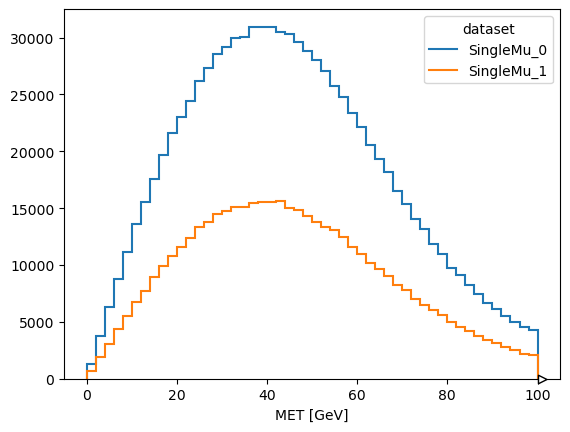

In [1]:
import sys
sys.path.insert(0, "..")

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, render
from coffea_workflow import facilities
from analysis import get_fileset, run_analysis, plot_results

# run_analysis receives an executor at runtime — user shouldn't define it in the analysis code.
step_fileset = Step(name="Fileset", step_type=Fileset, builder=get_fileset)
step_analysis = Step(name="Analysis", step_type=Analysis, builder=run_analysis)
step_plotting = Step(name="Plotting", step_type=Plotting, builder=plot_results)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

facility = facilities.CoffeaCasaFactory(
    worker_packages=("git+https://github.com/hooloobooroodkoo/coffea.git@processor_result_type",),
    worker_files=("../analysis.py",),
)
config = RunConfig(
    strategy="by_dataset",
    percentage=20,
    cache_dir=".cache_coffea_casa_dask_bug_check",
    facility=facility,
    executor_config=ExecutorConfig(executor_type="DaskExecutor"),
)

render(workflow, config)